In [ ]:
from google.colab import auth
from google.colab import drive
from google.cloud import bigquery

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuration

In [ ]:
auth.authenticate_user()
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_ID = 'lendingclub-488900'
DATASET_ID = 'lendingclub'
TABLE_ID = 'loans_2007_2020'
FULL_TABLE = f'{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}'

client = bigquery.Client(project = PROJECT_ID)

def run_query(sql):
  """
  Execute SQL query and return DataFrame
  """
  return client.query(sql).to_dataframe()

In [ ]:
query = f"""
SELECT *
FROM {FULL_TABLE}
"""

df = run_query(query)
df

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,...,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag,int_rate_decimal,revol_util_decimal,bc_util_decimal,all_util_decimal,il_util_decimal,percent_bc_gt_75_decimal,dti_decimal,dti_joint_decimal,sec_app_revol_util_decimal,pct_tl_nvr_dlq_decimal
0,122325,154410439,26925.00,26925.00,26925,60 months,16.12,656.49,C,C3,CEO,10+ years,OWN,134000.00,Verified,Jul-2019,Current,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,444xx,OH,14.01,0,...,CVD19SKIP,INCOME_CURTAILMENT,ACTIVE,4,0,May-2020,Jul-2020,May-2020,4,0,ACTIVE,2764.89,25851.57,532.76,N,0.16,0.39,0.21,0.60,0.79,0.00,0.14,NaN,NaN,1.00
1,128312,154972558,4800.00,4800.00,4800,36 months,20.00,178.39,D,D2,Admin assistant,10+ years,MORTGAGE,65000.00,Not Verified,Jul-2019,Current,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,Home improvement,895xx,NV,34.29,0,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,N,0.20,0.79,0.93,0.80,0.81,0.83,0.34,NaN,NaN,0.97
2,47944,161393194,3600.00,3600.00,3600,36 months,13.08,121.44,B,B5,caregiver,4 years,MORTGAGE,15000.00,Not Verified,Nov-2019,Current,n,https://lendingclub.com/browse/loanDetail.acti...,other,Other,874xx,NM,26.24,0,...,CVD19SKIP,REDUCED_HOURS,ACTIVE,2,0,May-2020,Jul-2020,May-2020,2,0,ACTIVE,97.04,3203.05,96.9,N,0.13,0.56,0.00,0.59,0.64,0.00,0.26,NaN,NaN,1.00
3,80166,160969355,35000.00,35000.00,35000,60 months,20.55,938.03,D,D2,Projects Manager,10+ years,MORTGAGE,62000.00,Verified,Nov-2019,Current,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,617xx,IL,23.50,0,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,N,0.21,0.01,0.00,0.75,0.85,0.00,0.23,NaN,NaN,0.91
4,6868,36391086,8000.00,8000.00,8000,36 months,12.39,267.21,C,C1,Manager,5 years,RENT,50000.00,Verified,Dec-2014,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,credit_card,Credit card refinancing,601xx,IL,14.38,1,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,N,0.12,0.32,0.38,NaN,NaN,0.50,0.14,NaN,NaN,0.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925487,28680,88057061,3500.00,3500.00,3500,36 months,7.99,109.67,A,A4,Senior Staff Engineer,1 year,MORTGAGE,62000.00,Not Verified,Aug-2016,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,Home improvement,327xx,FL,7.72,0,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,N,0.08,0.10,0.10,0.55,0.85,0.00,0.08,NaN,NaN,1.00
2925488,49814,7081743,20000.00,20000.00,20000,36 months,6.62,614.08,A,A2,Health first,10+ years,MORTGAGE,80000.00,Source Verified,Sep-2013,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,329xx,FL,19.58,0,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,N,0.07,0.35,0.39,NaN,NaN,0.29,0.20,NaN,NaN,0.97
2925489,59455,6577070,17625.00,17625.00,17625,60 months,17.56,443.36,D,D1,Massage Envy,5 years,RENT,40000.00,Verified,Aug-2013,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt,117xx,NY,22.77,0,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,N,0.18,0.34,0.34,NaN,NaN,0.12,0.23,NaN,NaN,1.00
2925490,77974,85571019,6000.00,6000.00,6000,36 months,12.79,201.56,C,C1,Senior Vice Presid

# Data Overview

In [ ]:
# Dataset Summary
query = f"""
SELECT
  COUNT(*) as total_loans,
  COUNT(DISTINCT id) as unique_loans,
  COUNT(DISTINCT grade) as num_grades,
  COUNT(DISTINCT addr_state) as num_states,
  COUNT(DISTINCT purpose) as num_purposes,
  ROUND(AVG(loan_amnt), 2) as avg_loan_amount,
  ROUND(AVG(int_rate), 2) as avg_funded_amount,
  ROUND(MIN(int_rate), 2) as min_rate,
  ROUND(MAX(int_rate), 2) as max_rate,
  MIN(issue_d) as earliest_issue_date,
  MAX(issue_d) as latest_issue_date
FROM {FULL_TABLE}
"""

overview = run_query(query)
print(overview.to_string(index=False))



 total_loans  unique_loans  num_grades  num_states  num_purposes  avg_loan_amount  avg_funded_amount  min_rate  max_rate earliest_issue_date latest_issue_date
     2925492       2925492           7          51            14         15358.78              13.05      5.31     30.99            Apr-2008          Sep-2020


In [ ]:
# Loan Status Distribution

query = f"""
select
  loan_status,
  count(*) as num_loans,
  round(count(*) * 100.0 / sum(count(*)) over(), 2) as percentage
from {FULL_TABLE}
group by loan_status
order by num_loans desc
"""

loan_status = run_query(query)
print(loan_status.to_string(index = False))


                                        loan_status  num_loans  percentage
                                         Fully Paid    1497783       51.20
                                            Current    1031016       35.24
                                        Charged Off     362548       12.39
                                 Late (31-120 days)      16154        0.55
                                    In Grace Period      10028        0.34
                                  Late (16-30 days)       2719        0.09
                                             Issued       2062        0.07
 Does not meet the credit policy. Status:Fully Paid       1988        0.07
Does not meet the credit policy. Status:Charged Off        761        0.03
                                            Default        433        0.01


In [ ]:
loan_status.columns

Index(['loan_status', 'num_loans', 'percentage'], dtype='object')

In [ ]:
# Default Rate
default_statuses = ['Charged off', 'Default',
                    'Does not meet the credit policy. Status:Charged Off',
                    'Late (31-120 days)', 'Late (16-30 days)']

total_loans = loan_status['num_loans'].sum()
defaulted_loans = loan_status[loan_status['loan_status'].isin(default_statuses)]['num_loans'].sum()
default_rate = (defaulted_loans / total_loans) * 100

print(f'overall Default Rate: {default_rate: 2f}%')

overall Default Rate:  0.685936%


In [ ]:
# Default Rates by Grade
query = f"""
select
  grade,
  count(*) as num_loans,
  countif(loan_status IN ('Charged Off', 'Default',
                            'Does not meet the credit policy. Status:Charged Off',
                            'Late (31-120 days)', 'Late (16-30 days)')) as defaulted_loans,
  round(countif(loan_status IN ('Charged Off', 'Default',
                            'Does not meet the credit policy. Status:Charged Off',
                            'Late (31-120 days)', 'Late (16-30 days)')) * 100.0 / count(*), 2) as default_rate_pct
  from {FULL_TABLE}
  where grade is not null
  group by grade
  order by grade
"""

defaults_by_grade = run_query(query)
defaults_by_grade

,grade,num_loans,defaulted_loans,default_rate_pct
0,A,656302,24590,3.75
1,B,857573,78821,9.19
2,C,802280,124661,15.54
3,D,416280,87476,21.01
4,E,139036,44930,32.32
5,F,41836,16762,40.07
6,G,12185,5375,44.11


In [ ]:
# Interest Rate By Grade
query = f"""
select
  grade,
  count(*) as num_loans,
  round(avg(int_rate), 2) as avg_rate,
  round(min(int_rate), 2) as min_rate,
  round(max(int_rate), 2) as max_rate,
  round(stddev(int_rate), 2) as std_rate,
  round(approx_quantiles(int_rate, 4)[offset(1)], 2) as q25,
  round(approx_quantiles(int_rate, 4)[offset(2)], 2) as q50,
  round(approx_quantiles(int_rate, 4)[offset(3)], 2) as q75
from {FULL_TABLE}
where grade is not null
group by grade
order by grade
"""

by_grade = run_query(query)
by_grade = by_grade.drop_duplicates(subset = ['grade'])
by_grade

,grade,num_loans,avg_rate,min_rate,max_rate,std_rate,q25,q50,q75
0,A,656302,7.36,5.31,10.81,1.08,6.49,7.39,8.19
1,B,857573,10.95,6.00,16.08,1.34,9.99,10.99,11.71
2,C,802280,14.49,6.00,20.74,1.48,13.49,14.30,15.31
3,D,416280,18.89,6.00,30.99,2.50,17.14,18.45,20.00
4,E,139036,21.91,6.00,29.00,2.74,19.52,21.60,23.99
5,F,41836,25.46,6.00,30.75,2.94,23.43,24.50,27.79
6,G,12185,28.08,6.00,30.99,2.81,25.89,28.18,30.79


In [ ]:
# Temporal Trends
query = f"""
select
   extract(year from parse_date('%b-%Y', issue_d)) as year,
  count(*) as num_loans,
  round(avg(loan_amnt), 2) as avg_amount,
  round(avg(int_rate), 2) as avg_rate,
  min(int_rate) as min_rate,
  max(int_rate) as max_rate,
  round(avg(dti), 2) as avg_dti,
  min(dti) as min_dti,
  max(dti) as max_dti,
  countif(loan_status in ('Charged Off', 'Default')) as defaults,
  round(countif(loan_status in ('Charged Off', 'Default')) * 100.0 / count(*), 2) as default_rate_pct
from {FULL_TABLE}
where issue_d is not null
group by year
order by year
"""

by_year = run_query(query)
by_year

,year,num_loans,avg_amount,avg_rate,min_rate,max_rate,avg_dti,min_dti,max_dti,defaults,default_rate_pct
0,2007,603,8254.52,11.83,7.12,17.86,10.71,0.00,28.73,45,7.46
1,2008,2393,8825.43,12.06,6.00,19.47,13.20,0.00,29.96,247,10.32
2,2009,5281,9833.03,12.44,6.00,21.21,12.47,0.00,24.99,594,11.25
3,2010,12537,10528.24,11.99,5.42,21.64,13.10,0.00,24.99,1487,11.86
4,2011,21721,12047.50,12.22,5.42,24.59,13.85,0.00,29.99,3297,15.18
5,2012,53367,13461.71,13.64,6.00,24.89,16.66,0.00,34.99,8644,16.20
6,2013,134814,14707.41,14.53,6.00,26.06,17.22,0.00,34.99,21027,15.60
7,2014,235629,14870.16,13.77,6.00,26.06,18.04,0.00,39.99,41748,17.72
8,2015,421095,15240.29,12.60,5.32,28.99,19.15,0.00,999.00,79712,18.93
9,2016,434407,14734.04,13.04,5.32,30.99,18.86,-1.00,999.00,79082,18.20


Debt-to-Income should not be -1.00 nor 999.000, this could be a sign that there are missing values in those entries and the system replaced the NAs with either -1 or 999.00.

In [ ]:
query = f"""
select
  count(*) as total_count,
  countif(dti is not null) as non_null_count,

  -- Percentiles using APPROX_Quantiles
  round(approx_quantiles(dti, 100)[offset(50)], 2) as p50_median,
  round(approx_quantiles(dti, 100)[offset(75)], 2) as p75,
  round(approx_quantiles(dti, 100)[offset(90)], 2) as p90,
  round(approx_quantiles(dti, 100)[offset(95)], 2) as p95,
  round(approx_quantiles(dti, 100)[offset(99)], 2) as p99,
  round(approx_quantiles(dti, 1000)[offset(999)], 2) as p99_9,

  -- Counts by range
  countif(dti < 0) as negative,
  countif(dti = 0) as zero,
  countif(dti > 0 and dti <= 50) as under_50,
  countif(dti > 50 and dti <= 100) as from_50_to_100,
  countif(dti > 100 and dti <= 200) as from_100_to_200,
  countif(dti > 200 and dti <= 500) as from_200_to_500,
  countif(dti > 500) as over_500,
  countif(dti = 999) as exactly_999,
  countif(dti >= 999) as at_least_999

from {FULL_TABLE}
"""

result = run_query(query)
print("DTI PERCENTILE ANALYSIS:")
print(f"   50th percentile (median): {result['p50_median'].values[0]:.2f}%")
print(f"   75th percentile: {result['p75'].values[0]:.2f}%")
print(f"   90th percentile: {result['p90'].values[0]:.2f}%")
print(f"   95th percentile: {result['p95'].values[0]:.2f}%")
print(f"   99th percentile: {result['p99'].values[0]:.2f}%")
print(f"   99.9th percentile: {result['p99_9'].values[0]:.2f}%")

print("DTI RANGE COUNTS:")
print(f"   Negative: {result['negative'].values[0]:,}")
print(f"   Zero: {result['zero'].values[0]:,}")
print(f"   0-50%: {result['under_50'].values[0]:,}")
print(f"   50-100%: {result['from_50_to_100'].values[0]:,}")
print(f"   100-200%: {result['from_100_to_200'].values[0]:,}")
print(f"   200-500%: {result['from_200_to_500'].values[0]:,}")
print(f"   500+%: {result['over_500'].values[0]:,}")
print(f"   Exactly 999: {result['exactly_999'].values[0]:,}")
print(f"   >= 999: {result['at_least_999'].values[0]:,}")

DTI PERCENTILE ANALYSIS:
   50th percentile (median): 18.09%
   75th percentile: 24.88%
   90th percentile: 31.14%
   95th percentile: 34.69%
   99th percentile: 48.17%
   99.9th percentile: 132.40%
DTI RANGE COUNTS:
   Negative: 2
   Zero: 2,353
   0-50%: 2,893,970
   50-100%: 21,151
   100-200%: 3,369
   200-500%: 1,093
   500+%: 446
   Exactly 999: 213
   >= 999: 213


Looking at the distribution of Debt-to-Income ratio shows that roughly 99% of the loans are between 0 and 100 dti.

In [ ]:
query = f"""
select
  sub_grade,
  count(*) as num_loans,

  -- DTI statistics (excluding outliers)
  round(avg(dti), 2) as avg_dti,
  round(min(dti), 2) as min_dti,
  round(max(dti), 2) as max_dti,
  round(approx_quantiles(dti, 100)[offset(25)], 2) as q25,
  round(approx_quantiles(dti, 100)[offset(50)], 2) as median,
  round(approx_quantiles(dti, 100)[offset(75)], 2) as q75,

  -- Interest rate for context
  round(avg(int_rate), 2) as avg_rate,

  -- Default rate
  round(countif(loan_status in ('Charged Off', 'Default')) * 100.0 / count(*), 2) as default_rate_pct

from {FULL_TABLE}
where sub_grade is not null and dti is not null
group by sub_grade
order by sub_grade
"""

by_subgrade = run_query(query)

by_subgrade

,sub_grade,num_loans,avg_dti,min_dti,max_dti,q25,median,q75,avg_rate,default_rate_pct
0,A1,133146,15.52,0.00,999.00,9.36,14.21,19.94,5.97,1.85
1,A2,100975,16.48,0.00,999.00,9.94,15.23,21.32,6.74,2.74
2,A3,106280,17.19,0.00,999.00,10.45,15.97,22.36,7.31,3.32
3,A4,158272,17.90,0.00,999.00,11.11,16.61,22.91,7.86,3.65
4,A5,157020,18.01,0.00,999.00,11.31,16.91,23.24,8.47,5.00
5,B1,163303,17.71,0.00,999.00,10.99,16.50,22.84,9.41,6.61
6,B2,164707,18.35,0.00,999.00,11.38,17.09,23.53,10.26,7.31
7,B3,162035,18.47,-1.00,999.00,11.70,17.36,23.81,10.92,8.93
8,B4,184999,19.03,0.00,999.00,12.07,17.86,24.39,11.64,9.37
9,B5,181668,19.32,0.00,999.00,12.19,18.13,24.77,12.30,10.63


Based on the distribution table of DTI by sub-grade above, the average DTI for each subgrade is closer to the minimum value than the maximum value. In addition, the percentile DTI range counts show that roughly 99% of the entire dataset has DTI within 0 to 100. Therefore, moving forward, the modeling section onward will only work with a subset of the data that contains loans with DTI between 0 and 100.

For default prediction, loans from 2019 to 2020 usually don't have time to default since it typically happens within 1 to 3 years after assignment. Therefore, two cleaned datasets are constructued:


1.   Cleaned Loans Dataset: Subset the data to keep loans that have DTI between 0-100 but keep of the years
2.   Matured Loans Dataset: Subset the data to keep loans that have DTI between 0-100 and only loans given between 2007 and 2018.



In [ ]:
#Cleaned Loan Dataset
client.query(f"""
create or replace table `{PROJECT_ID}.{DATASET_ID}.loans_clean as
select
  *,
  extract(year from parse_date('%b-%Y', issue_d)) as issue_year,
  cast(regexp_extract(term, r'(\d+)') as int64) as term_months,
  substr(sub_grade, 1, 1) as grade_letter,
  case when loan_status in ('Charged Off', 'Default',
                           'Does not meet the credit policy. Status:Charged Off')
       then 1 else 0 end as defaulted,
  case when loan_status in ('Fully Paid', 'Charged Off', 'Default',
                           'Does not meet the credit policy. Status:Charged Off',
                           'Does not meet the credit policy. Status:Fully Paid')
       then 1 else 0 end at completed
from {PROJECT_ID}.{DATASET_ID}.loans_2007_2020
where dti between 0 and 100 and loan_amnt > 0 and int_rate > 0 and annual_inc > 0
"""
).result()


# Mature Loans (For default prediction)
client.query(f"""
create or replace table `{PROJECT_ID}.{DATASET_ID}.loans_mature as
select * from {PROJECT_ID}.{DATASET_ID}.loans_clean
where completed = 1 and issue_year between 2007 and 2018
"""
).result()



In [ ]:
# Historical Economic Events
crisis_year = by_year[by_year['year'] == 2008]
covid_year = by_year[by_year['year'] == 2020]

if not crisis_year.empty:
  print(f'\n2008 Stats:')
  print(f'Loans: {crisis_year['num_loans'].values[0]:.2f}')
  print(f'Average Loan Rate: {crisis_year['avg_rate'].values[0]:.2f}%')
  print(f'Default Rate: {crisis_year['default_rate_pct'].values[0]:.2f}%')

if not covid_year.empty:
  print(f'\n2020 Stats:')
  print(f'Loans: {covid_year['num_loans'].values[0]:.2f}')
  print(f'Average Loan Rate: {covid_year['avg_rate'].values[0]:.2f}%')
  print(f'Default Rate: {covid_year['default_rate_pct'].values[0]:.2f}%')



2008 Stats:
Loans: 2393.00
Average Loan Rate: 12.06%
Default Rate: 10.32%

2020 Stats:
Loans: 146717.00
Average Loan Rate: 12.93%
Default Rate: 0.04%


In [ ]:
# Geographic Distribution
query = f"""
select
  addr_state,
  count(*) as num_loans,
  round(avg(int_rate), 2) as avg_rate,
  round(avg(loan_amnt), 2) as avg_amount,
  round(countif(loan_status in ('Charged Off', 'Default')) * 100.0 / count(*), 2) as default_rate
from {FULL_TABLE}
where addr_state is not null
group by addr_state
order by avg_rate desc
"""

by_state = run_query(query)
by_state

,addr_state,num_loans,avg_rate,avg_amount,default_rate
0,HI,13517,13.75,16234.04,13.55
1,AL,34726,13.53,14963.75,14.92
2,MS,16848,13.43,14935.77,14.69
3,AR,22252,13.35,14390.89,14.96
4,AK,6714,13.33,17493.51,12.27
5,ID,6817,13.28,14775.10,7.89
6,ND,5029,13.26,15780.73,9.78
7,TN,46953,13.24,15010.67,12.61
8,SC,36855,13.24,15266.38,9.49
9,MD,69747,13.23,16167.91,13.10


In [ ]:
# Loan Purpose
query = f"""
select
  purpose,
  count(*) as num_loans,
  round(avg(int_rate), 2) as avg_rate,
  min(int_rate) as min_rate,
  max(int_rate) as max_rate,
  round(avg(loan_amnt), 2) as avg_amount,
  round(countif(loan_status in ('Charged Off', 'Default')) * 100.0 / count(*), 2) as default_rate
from {FULL_TABLE}
where purpose is not null
group by purpose
order by avg_rate desc
"""

by_purpose = run_query(query)
by_purpose

,purpose,num_loans,avg_rate,min_rate,max_rate,avg_amount,default_rate
0,small_business,29976,14.98,5.31,30.99,16879.75,19.58
1,moving,19184,14.62,5.31,30.99,8599.31,15.21
2,renewable_energy,1767,14.45,5.31,30.99,11152.04,15.51
3,wedding,2355,14.15,5.42,25.99,10475.86,11.89
4,other,177488,14.15,5.31,30.99,10652.29,12.83
5,house,19596,14.08,5.31,30.99,15786.92,12.60
6,medical,35295,13.72,5.31,30.99,9528.75,13.07
7,vacation,20196,13.60,5.31,30.99,6434.28,11.76
8,debt_consolidation,1638058,13.47,5.31,30.99,16353.09,13.42
9,major_purchase,62685,12.85,5.31,30.99,12750.47,12.32


In [ ]:
# Credit Utilization
query = f"""
select
  round(avg(revol_util), 2) as avg_revol_util,
  round(avg(bc_util), 2) as avg_bc_util,
  round(avg(all_util), 2) as avg_all_util,
  round(avg(tot_hi_cred_lim), 2) as avg_credit_limit,
  min(tot_hi_cred_lim) as min_credit_limit,
  max(tot_hi_cred_lim) as max_credit_limit,
  round(avg(tot_cur_bal), 2) as avg_current_balance,
  min(tot_cur_bal) as min_current_balance,
  max(tot_cur_bal) as max_current_balance,
  round(avg(total_bal_ex_mort), 2) as avg_debt_ex_mortgages
from {FULL_TABLE}
where revol_util is not null
"""

utilization = run_query(query)
utilization

,avg_revol_util,avg_bc_util,avg_all_util,avg_credit_limit,min_credit_limit,max_credit_limit,avg_current_balance,min_current_balance,max_current_balance,avg_debt_ex_mortgages
0,48.99,55.92,56.27,183218.71,100.00,9999999.00,145347.03,0.00,9971659.00,52661.36


In [ ]:
query = f"""
select
  delinq_2yrs,
  num_tl_30dpd,
  num_tl_90g_dpd_24m,
  mths_since_last_delinq,
from {FULL_TABLE}
"""

delinquency = run_query(query)
delinquency.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925492 entries, 0 to 2925491
Data columns (total 4 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   delinq_2yrs             Int64 
 1   num_tl_30dpd            Int64 
 2   num_tl_90g_dpd_24m      object
 3   mths_since_last_delinq  object
dtypes: Int64(2), object(2)
memory usage: 94.9+ MB


In [ ]:
# Delinquency
query = f"""
select
  round(avg(delinq_2yrs), 2) as avg_delinq_2yrs,
  round(avg(num_tl_30dpd), 2) as avg_30dpd,
  round(avg(safe_cast(num_tl_90g_dpd_24m as float64)), 2) as avg_90dpd_24m, -- Str cast to float
  round(avg(safe_cast(mths_since_last_delinq as float64)), 2) as avg_mths_since_last_delinq, -- Str cast to float
  round(countif(delinq_2yrs > 0) * 100.0 / count(*), 2) as delinq_2yrs_pct,
  countif(delinq_2yrs > 0) as borrowers_with_delinq
from {FULL_TABLE}
where delinq_2yrs is not null
"""

delinquency = run_query(query)
delinquency

,avg_delinq_2yrs,avg_30dpd,avg_90dpd_24m,avg_mths_since_last_delinq,delinq_2yrs_pct,borrowers_with_delinq
0,0.29,0.00,0.08,34.95,17.72,518498


In [ ]:
# Income and DTI
query = f"""
SELECT
    ROUND(AVG(annual_inc), 2) as avg_income,
    ROUND(APPROX_QUANTILES(annual_inc, 4)[OFFSET(1)], 2) as income_q25,
    ROUND(APPROX_QUANTILES(annual_inc, 4)[OFFSET(2)], 2) as income_median,
    ROUND(APPROX_QUANTILES(annual_inc, 4)[OFFSET(3)], 2) as income_q75,
    ROUND(AVG(dti), 2) as avg_dti,
    ROUND(APPROX_QUANTILES(dti, 4)[OFFSET(1)], 2) as dti_q25,
    ROUND(APPROX_QUANTILES(dti, 4)[OFFSET(2)], 2) as dti_median,
    ROUND(APPROX_QUANTILES(dti, 4)[OFFSET(3)], 2) as dti_q75
FROM {FULL_TABLE}
WHERE annual_inc > 0 AND dti IS NOT NULL
"""
income_dti = run_query(query)
income_dti

,avg_income,income_q25,income_median,income_q75,avg_dti,dti_q25,dti_median,dti_q75
0,80022.84,47500.00,66000.00,95000.00,19.30,12.09,18.02,24.88


In [ ]:
# Joint Application
query = f"""
select
  application_type,
  count(*) as num_loans,
  round(avg(int_rate), 2) as avg_rate,
  avg(loan_amnt) as avg_amount,
  avg(annual_inc) as avg_income,
  round(countif(loan_status in ('Charged Off', 'Default')) * 100.0 / count(*), 2) as default_rate
from {FULL_TABLE}
where application_type is not null
group by application_type
order by num_loans desc
"""

joint_app = run_query(query)
joint_app

,application_type,num_loans,avg_rate,avg_amount,avg_income,default_rate
0,Individual,2714979,13.00,14993.44,81238.24,12.74
1,Joint App,210513,13.63,20070.52,63158.84,8.15


In [ ]:
# Hardship & Settlement Flags
query = f"""
select
  countif(hardship_flag = 'Y') as hardship_count,
  round(countif(hardship_flag = 'Y') * 100.0 / count(*), 2) as hardship_pct,
  countif(debt_settlement_flag = 'Y') as debt_settlement_count,
  round(countif(debt_settlement_flag = 'Y') * 100.0 / count(*), 2) as settlement_pct
from {FULL_TABLE}
"""

hardship_settlement = run_query(query)
hardship_settlement

,hardship_count,hardship_pct,debt_settlement_count,settlement_pct
0,121547,4.15,51471,1.76


#Visualization

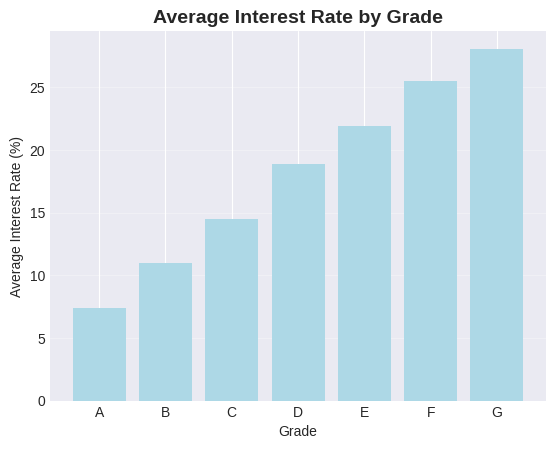

In [ ]:
# Plot 1: Interest rate by grade
plt.bar(by_grade['grade'], by_grade['avg_rate'], color = 'lightblue')
plt.title('Average Interest Rate by Grade', fontsize = 14, fontweight = 'bold')
plt.xlabel('Grade')
plt.ylabel('Average Interest Rate (%)')
plt.grid(axis = 'y', alpha = 0.3)

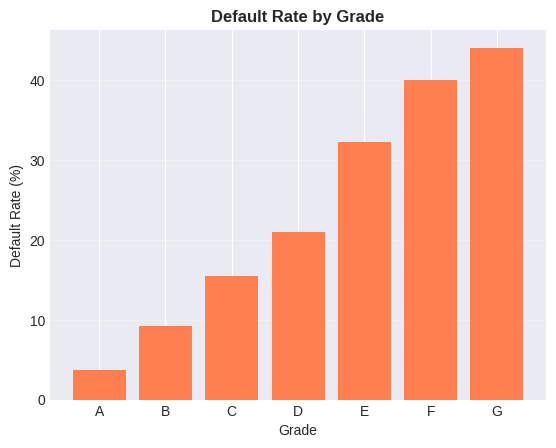

In [ ]:
plt.bar(defaults_by_grade['grade'], defaults_by_grade['default_rate_pct'],
        color='coral')
plt.title('Default Rate by Grade', fontsize=12, fontweight='bold')
plt.xlabel('Grade')
plt.ylabel('Default Rate (%)')
plt.grid(axis='y', alpha=0.3)